# TrappedAtomsSimulation_HarmonicPotential

Author: Paul Christ

Date: 04.11.2025


In [1]:
# Import
from TrappedAtomsSimulation.initialization import initialize_one_temp_gaussian_state, initialize_two_temp_gaussian_state
from TrappedAtomsSimulation.force_calculation import calculate_interaction_strength
from TrappedAtomsSimulation.force_calculation import pair_keops_fp
from TrappedAtomsSimulation.integrators import run_verlet_simulation_HO, solve_harmonic_analytical
from TrappedAtomsSimulation.plot_utils import plot_energy_and_error, plot_thermalization

import torch

In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32

## Trap

In [3]:
trap_frequencies_Hz = (1000.0, 1000.0, 3000.0)

### One group

--- Skalierung basierend auf T = 1.00e-06 K ---
Längenskala L0: 1.56e-06 m, Energieskala E0: 1.38e-29 J, Zeitskala T0: 1.59e-04 s
Initialisiere 20000 Teilchen bei T = 1.00e-06 K
--- Initialisierung abgeschlossen ---



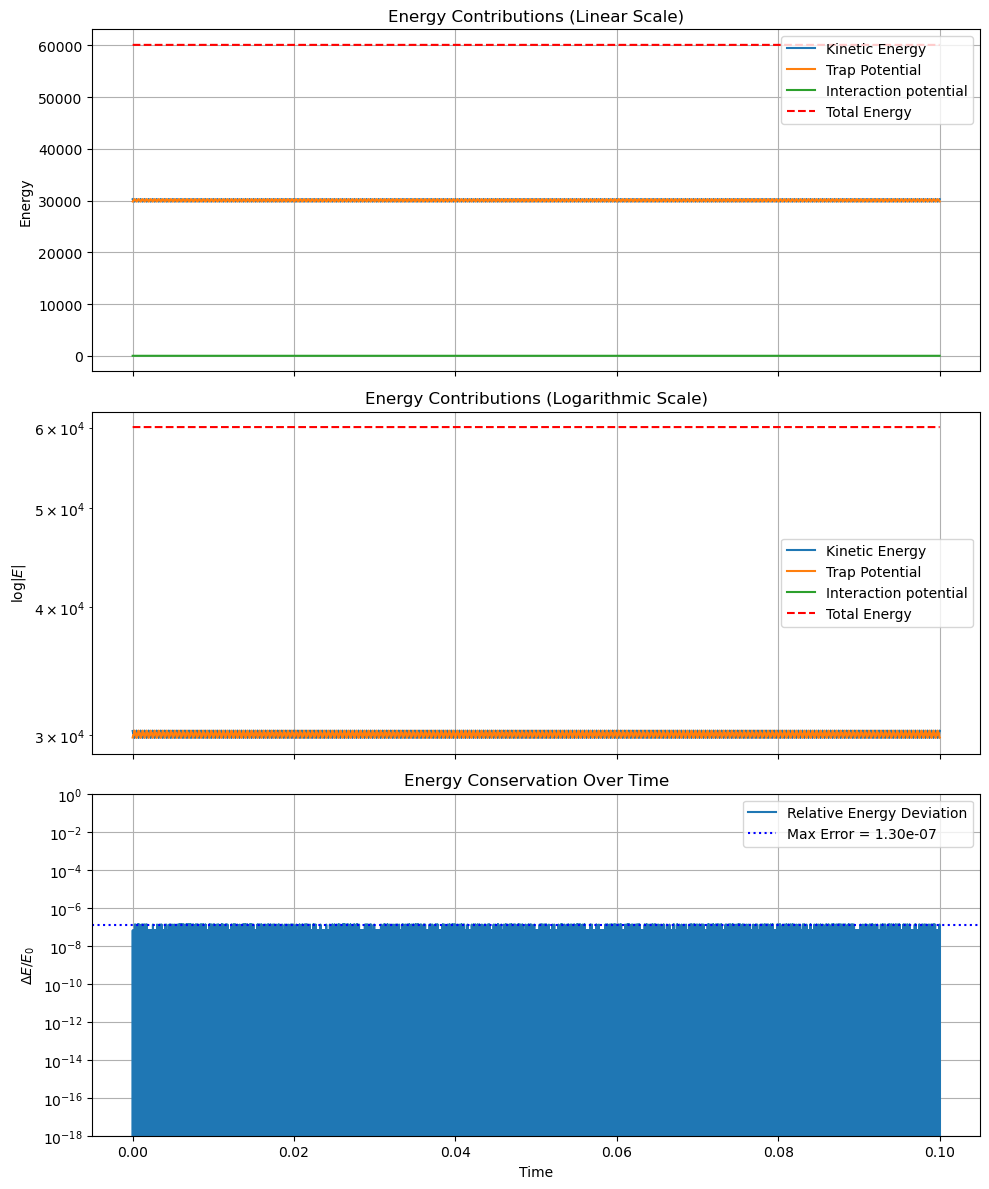

tensor(1.3004e-07, device='cuda:0')

In [4]:
# exakte lösung
simulation_time_s = 0.1
timestep_s = 1e-5
substeps = 10
n_particles = 20000
T = 1e-6

initial_state_params = initialize_one_temp_gaussian_state(
    n_particles=n_particles,
    temp_k=T,
    omega_phys_hz=trap_frequencies_Hz,
    t_end_s=simulation_time_s,
    dt_s=timestep_s,
    r0_phys=None,   
    C_phys=None,    
    precision=dtype,
    device=device
)

integrator_config = {
    "pair_force_func": None, # (wird ignoriert)
    "substeps": 1             # (wird ignoriert, da exakte lösung)
}

simulation_input_args = {**initial_state_params, **integrator_config}


# ---  Berechnung starten ---

results_analytical = solve_harmonic_analytical(**simulation_input_args)

## achtung SI zeit aber dimless energies
T0 = initial_state_params["T0_s"] 
plot_energy_and_error(results_analytical['times'] * T0, results_analytical['kinetic_energy'],results_analytical['potential_energy_harmonic'],results_analytical['potential_energy_pair'])

(5.237793946e-08, 2.2412044211712406e-30)
--- Skalierung basierend auf T = 1.00e-06 K ---
Längenskala L0: 1.56e-06 m, Energieskala E0: 1.38e-29 J, Zeitskala T0: 1.59e-04 s
Initialisiere 200000 Teilchen bei T = 1.00e-06 K
--- Initialisierung abgeschlossen ---

Integration 100% | Time: 0 min 0 ss

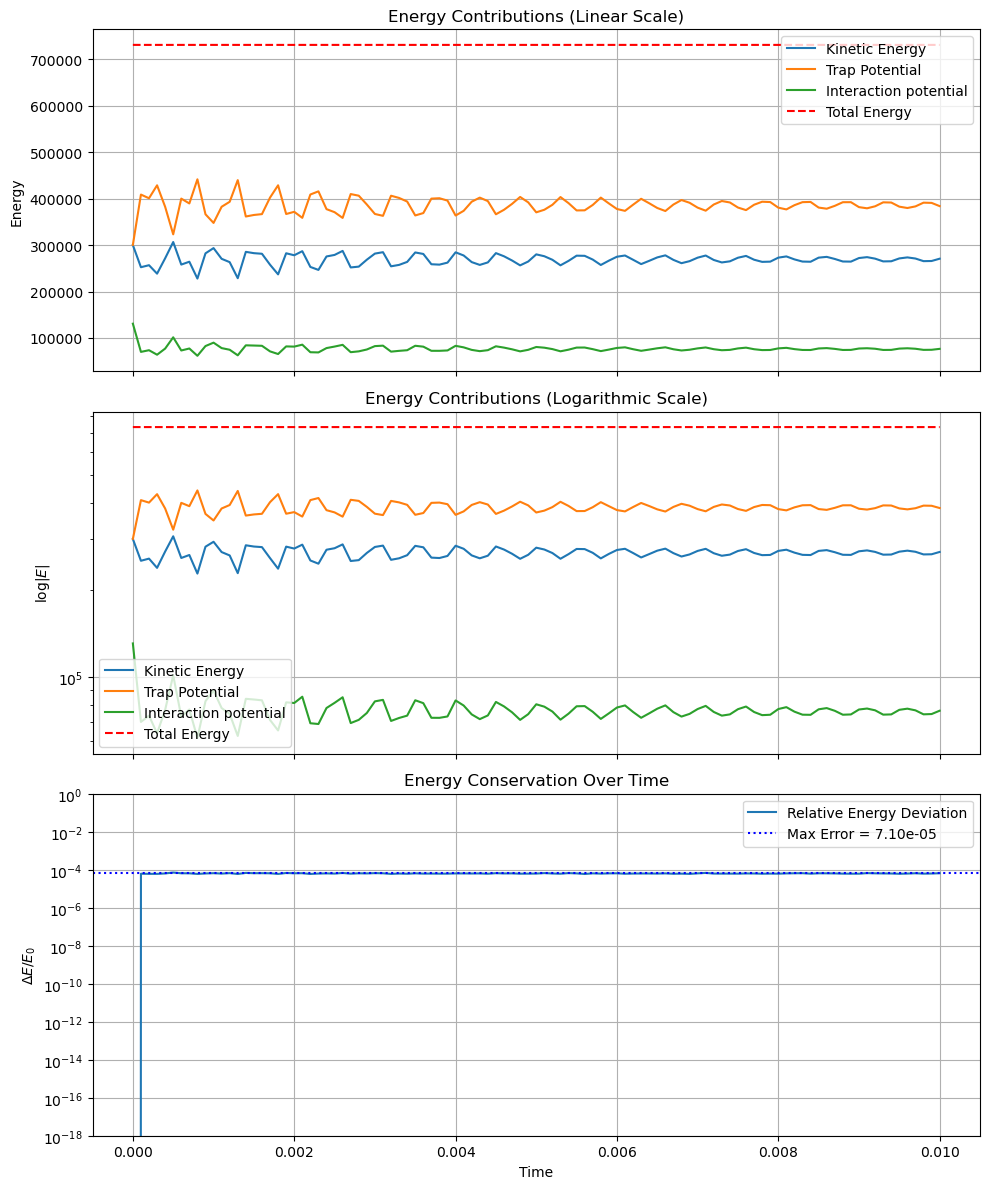

tensor(7.1003e-05, device='cuda:0')

In [7]:
# eine gruppe
simulation_time_s = 0.01
timestep_s = 1e-4
substeps = 100
n_particles = 200000
T = 1e-6

r0_phys,C_phys = calculate_interaction_strength(10)
print((r0_phys,C_phys))


initial_state_params = initialize_one_temp_gaussian_state(
    n_particles=n_particles,
    temp_k=T,
    omega_phys_hz=trap_frequencies_Hz,
    t_end_s=simulation_time_s,
    dt_s=timestep_s,
    r0_phys=r0_phys,
    C_phys=C_phys,
    precision=dtype,
    device=device
)

integrator_config = {
    "pair_force_func": pair_keops_fp,
    "substeps": substeps
}

simulation_input_args = {**initial_state_params, **integrator_config}

# --- Simulation starten ---
simulation_results = run_verlet_simulation_HO(**simulation_input_args)
T0 = initial_state_params["T0_s"] 
plot_energy_and_error(simulation_results['times']*T0, simulation_results['kinetic_energy'],simulation_results['potential_energy_harmonic'],simulation_results['potential_energy_pair'])

### Two groups

(5.237793946e-08, 2.2412044211712406e-30)
--- Skalierung basierend auf Referenztemperatur T_ref = 1.00e-06 K ---
Längenskala L0: 1.56e-06 m, Energieskala E0: 1.38e-29 J, Zeitskala T0: 1.59e-04 s
Initialisiere Gruppe mit 10000 Teilchen bei T = 1.00e-06 K
Initialisiere Gruppe mit 10000 Teilchen bei T = 2.00e-06 K
Skaliere Interaktionsparameter...
--- Zwei-Temperatur-Initialisierung abgeschlossen ---

Integration 100% | Time: 0 min 0 s

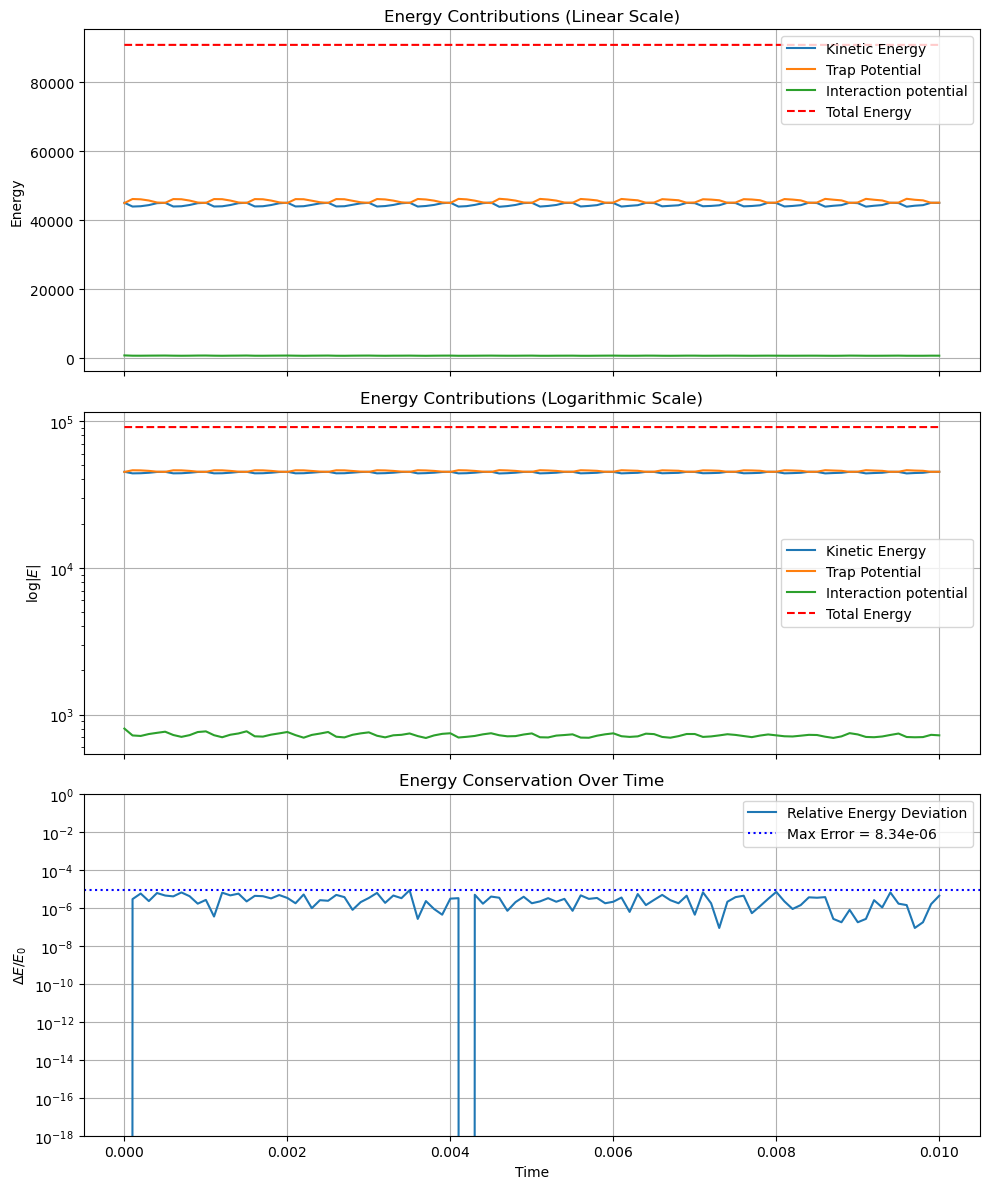

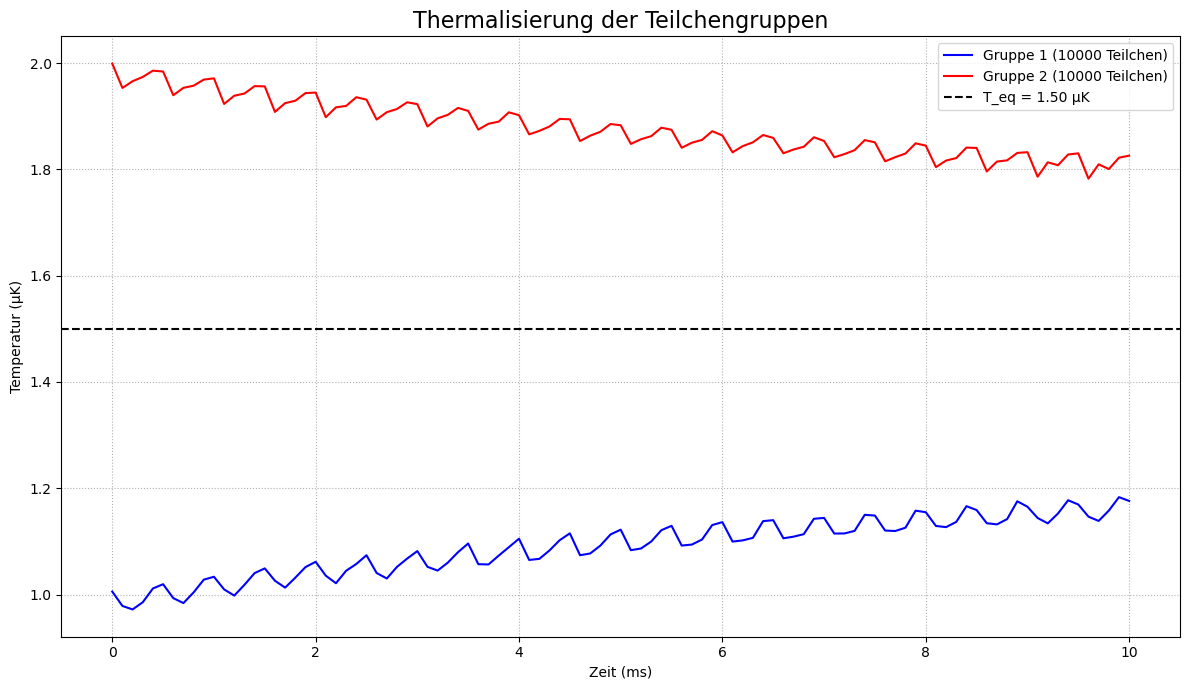

In [6]:
n_groups = (10000, 10000) # 2000 kalte, 1000 heiße Teilchen
temp_groups = (1e-6, 2e-6)
simulation_time_s = 0.01
timestep_s = 1e-4
substeps = 100
T = 1e-6

r0_phys,C_phys = calculate_interaction_strength(10)
print((r0_phys,C_phys))

initial_state_params = initialize_two_temp_gaussian_state(
    n_particles_groups = n_groups,
    temp_k_groups = temp_groups ,
    omega_phys_hz=trap_frequencies_Hz,
    t_end_s=simulation_time_s,
    dt_s=timestep_s,
    r0_phys=r0_phys,
    C_phys=C_phys,
    precision=dtype,
    device=device
)


integrator_config = {
    "pair_force_func": pair_keops_fp,
    "substeps": substeps
}

simulation_input_args = {**initial_state_params, **integrator_config}


# --- Simulation starten ---
simulation_results = run_verlet_simulation_HO(**simulation_input_args)
T0 = initial_state_params["T0_s"] 
plot_energy_and_error(simulation_results['times'] * T0, simulation_results['kinetic_energy'],simulation_results['potential_energy_harmonic'],simulation_results['potential_energy_pair'])
plot_thermalization(
        results=simulation_results,
        n_groups=n_groups,
        temp_groups=temp_groups,
        T0_s=T0 
    )